# <center>MLPClassifier</center>
<ul>
    <li>MLPClassifier pertenece a la categoria de Machine Learning aprendisaje supervisado basada en redes neuronas, en donde clasifica los datos en multiples capas o redes neuronales</li>

# 1. Importamos las librerias a utilizar para nuestro modelo MLPClassifier

In [33]:
from sklearn.model_selection import GroupKFold, KFold, cross_validate, train_test_split, GridSearchCV,cross_val_score
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score,precision_score, recall_score, f1_score
import pandas as pd
import numpy as np
# Librearias para el uso de graficas
from pandas.plotting import scatter_matrix
from string import ascii_letters
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Importamos y visualizamos nuestro dataSet utilizando pandas

In [2]:
data=pd.read_csv("data/dataSetpH.csv",encoding='latin-1')
data.head(2)

,SQUARE,PLOT,ANO,PH,LOI,C_CONC_LOI,C_STOCK_LOI,BULK_DENSITY,MOISTURE,N_PERCENT,N_STOCK,PO4_OLSEN,LC07,LC07_NUM,COUNTRY,COUNTY07,EZ_DESC_07,STATE_PH,STATE_NUMBER
0,AZFZMV,JQWCHLFHEI,2007,4.31,93.98097,516.895335,78.471725,0.101209,86.396896,NaN,NaN,NaN,31s,39,SCO,Shetland Islands,Intermediate uplands and Islands (Scotland),Fuertemenete Ácido,2.0
1,AZFZMV,TBVIDVQSYN,2007,4.26,95.67244,526.198420,105.353200,0.133477,83.977858,NaN,NaN,NaN,31s,39,SCO,Shetland Islands,Intermediate uplands and Islands (Scotland),Fuertemenete Ácido,2.0


# 3. Realizamos un análisis de nuestros conjuntos de datos para identificar posibles datos faltantes o excedentes.

In [3]:
data.isnull().sum()

SQUARE             0
PLOT               0
ANO                0
PH                 1
LOI               31
C_CONC_LOI        31
C_STOCK_LOI       75
BULK_DENSITY      75
MOISTURE          50
N_PERCENT       1641
N_STOCK         1655
PO4_OLSEN       1601
LC07               0
LC07_NUM           0
COUNTRY            0
COUNTY07           0
EZ_DESC_07         0
STATE_PH           1
STATE_NUMBER       1
dtype: int64

# 4. Eliminamos nuestros datos faltantes para que estén limpios y listos para su análisis

In [4]:
data.dropna(subset=["PH", "STATE_PH","STATE_NUMBER"], inplace=True)
data['STATE_PH_INT'] = data['STATE_NUMBER'].astype(int)

In [5]:
datos_asc = data.sort_values("PH", ascending=True)  # ordenamos nuestros datos de menor a mayor 
x_asc = datos_asc[["PH"]]
y_asc = datos_asc["STATE_PH_INT"]
datos_asc.head(2)

,SQUARE,PLOT,ANO,PH,LOI,C_CONC_LOI,C_STOCK_LOI,BULK_DENSITY,MOISTURE,N_PERCENT,N_STOCK,PO4_OLSEN,LC07,LC07_NUM,COUNTRY,COUNTY07,EZ_DESC_07,STATE_PH,STATE_NUMBER,STATE_PH_INT
304,HIZWNL,MIOUKRJLOG,2007,3.31,89.361920,491.490560,95.759693,0.129890,84.964290,NaN,NaN,NaN,19e,21,ENG,Northumberland,Uplands (England),Extremadamente Ácido,1.0,1
1070,KLOORS,GPVDGZNSYG,2007,3.32,7.527621,41.401916,56.058643,0.902674,34.730047,0.22,2.978824,3.0,6w,42,WAL,West Glamorgan,Lowlands (Wales),Extremadamente Ácido,1.0,1


# 5. Entrenamos nuestro modelo con los datos optmizados para nuestro modelo de DecisionTreeClassifier

In [6]:
x_train,x_test,y_train,y_test=train_test_split(x_asc,y_asc)
model=MLPClassifier(hidden_layer_sizes=(256,128,64,32),activation="relu",random_state=1)

In [7]:
model.fit(x_train,y_train)
predict=model.predict(x_test)

accuracy=accuracy_score(y_test,predict)

In [8]:
valores_PH = [4.5, 6.3, 7.02, 8.1, 9]
nuevos_datos = pd.DataFrame({'PH': valores_PH})
predicciones_nuevos_datos = model.predict(nuevos_datos)
print(f"Tasa acierto de nuestro modelo es de: {round(accuracy*100,2)} %")
print("Predicciones segun el pH:")
for ph, pred in zip(valores_PH, predicciones_nuevos_datos):
    print(f"PH: {ph}, Clasificación: {pred}")

Tasa acierto de nuestro modelo es de: 97.13 %
Predicciones segun el pH:
PH: 4.5, Clasificación: 2
PH: 6.3, Clasificación: 4
PH: 7.02, Clasificación: 5
PH: 8.1, Clasificación: 7
PH: 9, Clasificación: 7


# 6. Ahora buscaremos optimizar nuestro modelo mediante la ajuste de parámetros, con el objetivo de obtener predicciones más realistas y acordes a nuestras necesidades.

In [9]:
def train_mlp(hidden_layer_sizes, x_asc, y_asc, data):
    SEED = 301
    np.random.seed(SEED)

    cv = GroupKFold(n_splits=8)
    modelo = MLPClassifier(hidden_layer_sizes=hidden_layer_sizes, random_state=SEED,max_iter=4000)
    results = cross_validate(modelo, x_asc, y_asc, cv=cv, groups=data.STATE_PH_INT, return_train_score=True)
    
    train_score = results['train_score'].mean() * 100
    test_score = results['test_score'].mean() * 100
    print(f'MLP Classifier hidden_layer_sizes = {hidden_layer_sizes}, training = {train_score:.2f}, testing = {test_score:.2f}')
     
    tabla = [hidden_layer_sizes, round(train_score, 2), round(test_score, 2)]
    return tabla

def main():
    resultados_df = [
        train_mlp(hidden_layer_sizes=i, x_asc=x_asc, y_asc=y_asc, data=data)
        for i in range(1, 28)  
    ]

    resultados_df = pd.DataFrame(resultados_df, columns=['hidden_layer_sizes', 'train', 'test'])
    print(f"\n")
    return {'table': resultados_df.head(len(resultados_df)), 'result': resultados_df}

result_main = main()
value_table = result_main['table']
# El resultado mas obtimo que se tuvo fue hidden_layer_sizes = 18

MLP Classifier hidden_layer_sizes = 1, training = 25.20, testing = 20.68
MLP Classifier hidden_layer_sizes = 2, training = 98.59, testing = 98.15
MLP Classifier hidden_layer_sizes = 3, training = 98.78, testing = 98.50
MLP Classifier hidden_layer_sizes = 4, training = 99.19, testing = 99.39
MLP Classifier hidden_layer_sizes = 5, training = 99.23, testing = 99.13
MLP Classifier hidden_layer_sizes = 6, training = 99.30, testing = 99.08
MLP Classifier hidden_layer_sizes = 7, training = 99.43, testing = 99.36
MLP Classifier hidden_layer_sizes = 8, training = 99.41, testing = 99.39
MLP Classifier hidden_layer_sizes = 9, training = 98.92, testing = 99.00
MLP Classifier hidden_layer_sizes = 10, training = 99.25, testing = 99.22
MLP Classifier hidden_layer_sizes = 11, training = 99.10, testing = 99.30
MLP Classifier hidden_layer_sizes = 12, training = 99.01, testing = 98.94
MLP Classifier hidden_layer_sizes = 13, training = 99.36, testing = 99.38
MLP Classifier hidden_layer_sizes = 14, trainin

<AxesSubplot:xlabel='hidden_layer_sizes', ylabel='train'>

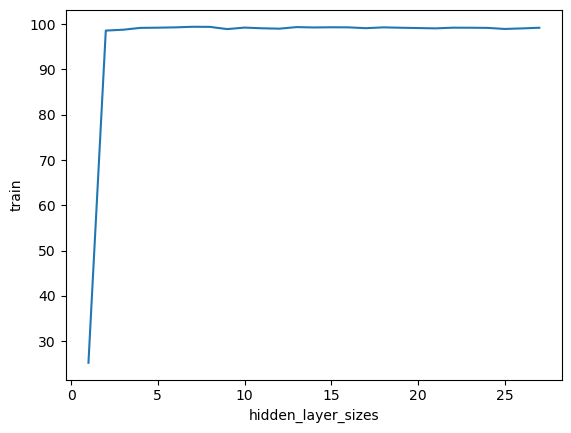

In [10]:
sns.lineplot(x='hidden_layer_sizes', y='train', data=result_main['result'])

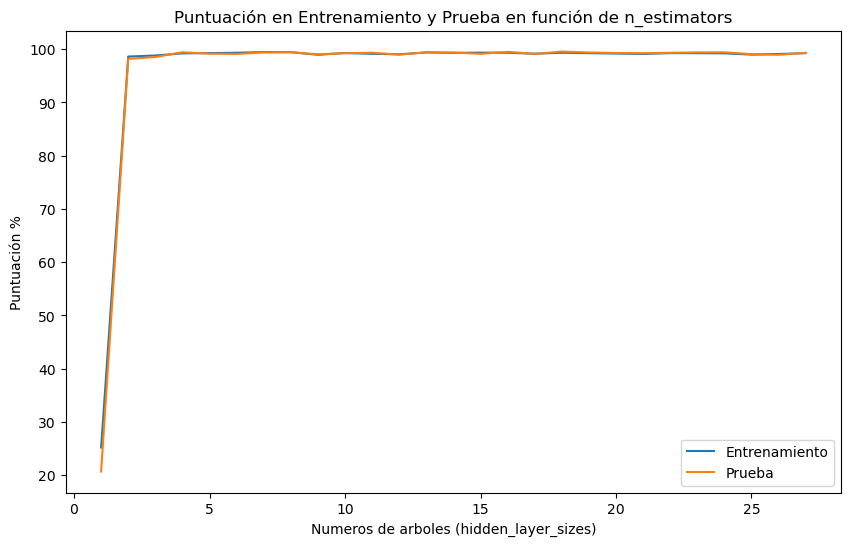

In [11]:
plt.figure(figsize=(10, 6))
sns.lineplot(x='hidden_layer_sizes', y='train', data=result_main['result'], label='Entrenamiento')
sns.lineplot(x='hidden_layer_sizes', y='test', data=result_main['result'], label='Prueba')
plt.xlabel('Capas de red neuronal  (hidden_layer_sizes)')
plt.ylabel('Puntuación %')
plt.title('Puntuación en Entrenamiento y Prueba en función de hidden_layer_sizes')

plt.legend()
plt.show()

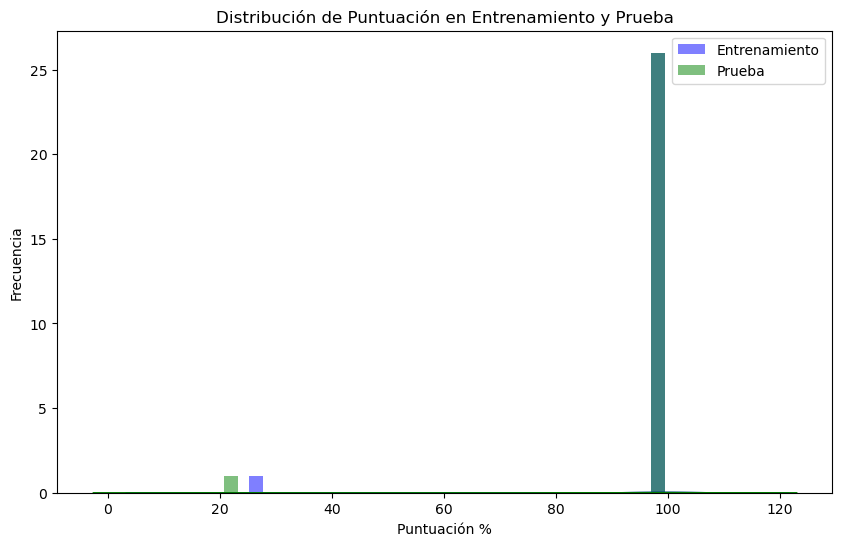

In [12]:
plt.figure(figsize=(10, 6))


plt.hist(value_table['train'], bins=30, label='Entrenamiento', alpha=0.5, color='blue')
plt.hist(value_table['test'], bins=30, label='Prueba', alpha=0.5, color='green')

# KDE plots
sns.kdeplot(value_table['train'], fill=True, color='blue')
sns.kdeplot(value_table['test'], fill=True, color='green')


plt.xlabel('Puntuación %')
plt.ylabel('Frecuencia')
plt.title('Distribución de Puntuación en Entrenamiento y Prueba')
plt.legend()

plt.show()


# 7. A continuación, continuamos explorando parámetros para la optimización de nuestro código. En esta ocasión, añadiremos 'min_samples_leaf' como un parámetro a nuestro DecisionTreeClassifier.
* min_samples_leaf: Cantidad mínima de muestras requeridas en las hojas de nuestro árbol.

In [13]:
def train_mlp1(hidden_layer_sizes, alpha, x_asc, y_asc, data):
    SEED = 301
    np.random.seed(SEED)

    cv = GroupKFold(n_splits=8)
    modelo = MLPClassifier(hidden_layer_sizes=hidden_layer_sizes, alpha=alpha, random_state=SEED, max_iter=4000)
    results = cross_validate(modelo, x_asc, y_asc, cv=cv, groups=data.STATE_PH_INT, return_train_score=True)
    
    train_score = results['train_score'].mean() * 100
    test_score = results['test_score'].mean() * 100
    
    print(f'MLP hidden_layer_sizes = {hidden_layer_sizes}, alpha = {alpha}, training = {train_score:.2f}, testing = {test_score:.2f}')
    tabla = [hidden_layer_sizes, alpha, train_score, test_score]
    return tabla

def search_best_mlp_results1(x_asc, y_asc, data):
    resultados = []
    for hidden_layer_sizes in range(1, 28): 
        for alpha in [0.0001, 0.001, 0.01]:
            tabla = train_mlp1(hidden_layer_sizes, alpha, x_asc, y_asc, data)
            resultados.append(tabla)
            
    resultados = pd.DataFrame(resultados, columns=['hidden_layer_sizes', 'alpha', 'train', 'test'])
    return resultados.head(50)

result_mlp1 = search_best_mlp_results1(x_asc, y_asc, data)
# for i in [(5, 2), (10, 5), (20, 10)]:

# mejor resultado de las pruebas con hidden_layer_sizes in [(5, 2), (10, 5), (20, 10)]:  fue de: 
# MLP hidden_layer_sizes = (20, 10), alpha = 0.001
# Entrenamiento: 99.23
# Prueba: 99.38
# resultados con in in  range(1, 28)
# MLP hidden_layer_sizes = 18, alpha = 0.0001, training = 99.30, testing = 99.52

MLP hidden_layer_sizes = 1, alpha = 0.0001, training = 25.20, testing = 20.68
MLP hidden_layer_sizes = 1, alpha = 0.001, training = 67.39, testing = 67.60
MLP hidden_layer_sizes = 1, alpha = 0.01, training = 81.07, testing = 80.38
MLP hidden_layer_sizes = 2, alpha = 0.0001, training = 98.59, testing = 98.15
MLP hidden_layer_sizes = 2, alpha = 0.001, training = 99.24, testing = 99.30
MLP hidden_layer_sizes = 2, alpha = 0.01, training = 98.98, testing = 99.01
MLP hidden_layer_sizes = 3, alpha = 0.0001, training = 98.78, testing = 98.50
MLP hidden_layer_sizes = 3, alpha = 0.001, training = 98.66, testing = 98.47
MLP hidden_layer_sizes = 3, alpha = 0.01, training = 98.64, testing = 98.33
MLP hidden_layer_sizes = 4, alpha = 0.0001, training = 99.19, testing = 99.39
MLP hidden_layer_sizes = 4, alpha = 0.001, training = 99.16, testing = 99.39
MLP hidden_layer_sizes = 4, alpha = 0.01, training = 99.05, testing = 99.24
MLP hidden_layer_sizes = 5, alpha = 0.0001, training = 99.23, testing = 99.1

In [14]:
corr1 = result_mlp1.corr()
corr1

,hidden_layer_sizes,alpha,train,test
hidden_layer_sizes,1.000000,-0.048279,0.358683,0.356231
alpha,-0.048279,1.000000,0.085126,0.085001
train,0.358683,0.085126,1.000000,0.999644
test,0.356231,0.085001,0.999644,1.000000


In [15]:
#result_mlp1

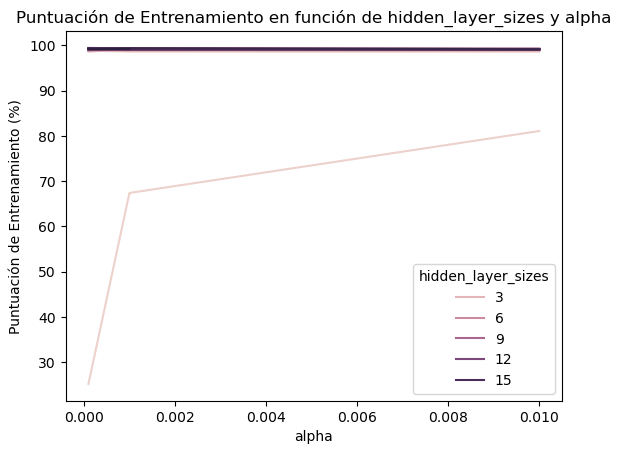

In [17]:
sns.lineplot(data=result_mlp1, x='alpha', y='train', hue='hidden_layer_sizes')
#sns.lineplot(data=result1, x='max_depth', y='test', hue='min_samples_leaf')
plt.title('Puntuación de Entrenamiento en función de hidden_layer_sizes y alpha')
plt.xlabel('alpha')
plt.ylabel('Puntuación de Entrenamiento (%)')
plt.legend(title='hidden_layer_sizes')
plt.show()

# 9. Explorando 3 dimensiones de hiper parámetros

In [18]:
def train_mlp2(hidden_layer_size, alpha, batch_size, x_asc, y_asc, data):
    cv = GroupKFold(n_splits=8)
    hidden_layer_sizes = (hidden_layer_size,)  
    modelo = MLPClassifier(hidden_layer_sizes=hidden_layer_sizes, alpha=alpha, batch_size=batch_size, max_iter=4000)
    results = cross_validate(modelo, x_asc, y_asc, cv=cv, groups=data.STATE_PH_INT, return_train_score=True)
    
    fit_time    = results['fit_time'].mean()
    score_time  = results['score_time'].mean()
    train_score = results['train_score'].mean() * 100
    test_score  = results['test_score'].mean() * 100
    
    print(f'Hidden Layer Size = {hidden_layer_size}, Alpha = {alpha}, Batch Size = {batch_size}, training = {train_score:.2f}, testing = {test_score:.2f}')

    tabla = [hidden_layer_size, alpha, batch_size, train_score, test_score, fit_time, score_time]
    return tabla

def Search_Best_Result2(x_asc, y_asc, data):
    resultados = []
    alpha_values = [0.0001, 0.001, 0.01, 0.1]
    batch_size_values = [32, 64, 128, 256]

    for hidden_layer_size in range(1, 28):
        for alpha in alpha_values:
            for batch_size in batch_size_values:
                tabla = train_mlp2(hidden_layer_size, alpha, batch_size, x_asc, y_asc, data)
                resultados.append(tabla)

    resultados_df = pd.DataFrame(resultados, columns=['hidden_layer_size', 'alpha', 'batch_size', 'train', 'test', 'fit_time', 'score_time'])
    return resultados_df

x_asc = np.array(x_asc)
y_asc = np.array(y_asc)

result_mlp2 = Search_Best_Result2(x_asc, y_asc, data)
result_mlp2.head(50)
#[0.0001, 0.001, 0.01]:

Hidden Layer Size = 1, Alpha = 0.0001, Batch Size = 32, training = 62.74, testing = 59.91
Hidden Layer Size = 1, Alpha = 0.0001, Batch Size = 64, training = 56.95, testing = 54.12
Hidden Layer Size = 1, Alpha = 0.0001, Batch Size = 128, training = 47.26, testing = 41.09
Hidden Layer Size = 1, Alpha = 0.0001, Batch Size = 256, training = 70.77, testing = 71.24
Hidden Layer Size = 1, Alpha = 0.001, Batch Size = 32, training = 75.05, testing = 73.79
Hidden Layer Size = 1, Alpha = 0.001, Batch Size = 64, training = 65.08, testing = 59.67
Hidden Layer Size = 1, Alpha = 0.001, Batch Size = 128, training = 78.66, testing = 77.99
Hidden Layer Size = 1, Alpha = 0.001, Batch Size = 256, training = 70.73, testing = 69.06
Hidden Layer Size = 1, Alpha = 0.01, Batch Size = 32, training = 74.44, testing = 76.25
Hidden Layer Size = 1, Alpha = 0.01, Batch Size = 64, training = 89.73, testing = 90.75
Hidden Layer Size = 1, Alpha = 0.01, Batch Size = 128, training = 65.36, testing = 62.29
Hidden Layer Si

,hidden_layer_size,alpha,batch_size,train,test,fit_time,score_time
0,1,0.0001,32,62.738934,59.913777,29.000265,0.000367
1,1,0.0001,64,56.952904,54.118687,17.292242,0.000561
2,1,0.0001,128,47.260774,41.093361,8.888003,0.000611
3,1,0.0001,256,70.772489,71.237268,13.092487,0.000580
4,1,0.0010,32,75.051747,73.792891,43.906702,0.000490
5,1,0.0010,64,65.078851,59.674434,20.317916,0.000858
6,1,0.0010,128,78.661628,77.990339,24.920024,0.000978
7,1,0.0010,256,70.725163,69.055546,11.878216,0.000856
8,1,0.0100,32,74.439194,76.252084,55.217147,0.000997
9,1,0.0100,64,89.727140,90.752812,39.391155,0.000823


In [19]:
corr2 = result_mlp2.corr()
corr2

,hidden_layer_size,alpha,batch_size,train,test,fit_time,score_time
hidden_layer_size,1.000000e+00,5.909115e-17,2.110947e-16,0.433982,0.428075,-0.497121,-0.038504
alpha,5.909115e-17,1.000000e+00,5.722520e-18,-0.062195,-0.057115,-0.005925,-0.089588
batch_size,2.110947e-16,5.722520e-18,1.000000e+00,0.017033,0.012971,-0.529438,0.001954
train,4.339825e-01,-6.219451e-02,1.703334e-02,1.000000,0.996598,-0.190511,0.025554
test,4.280755e-01,-5.711488e-02,1.297137e-02,0.996598,1.000000,-0.176780,0.028374
fit_time,-4.971215e-01,-5.925374e-03,-5.294378e-01,-0.190511,-0.176780,1.000000,0.071149
score_time,-3.850352e-02,-8.958820e-02,1.953957e-03,0.025554,0.028374,0.071149,1.000000


In [ ]:
result2.sort_values('test', ascending = False).head()

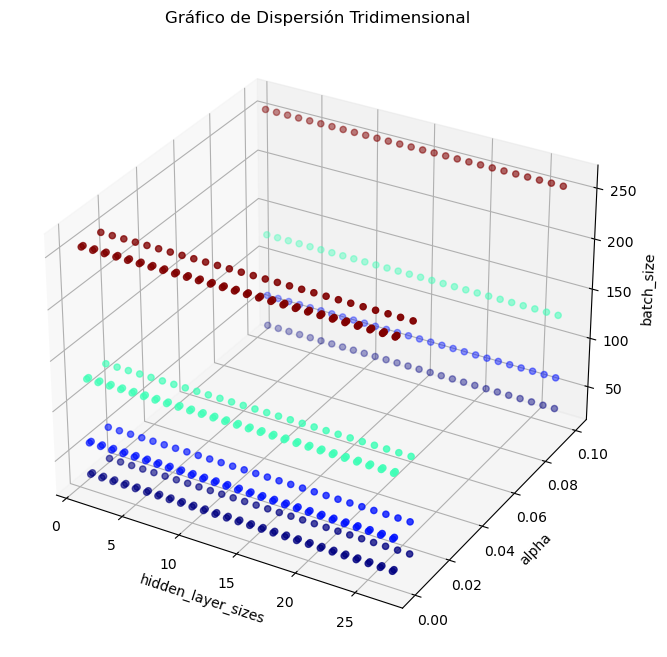

In [21]:
x = result_mlp2['hidden_layer_size']
y = result_mlp2['alpha']
z = result_mlp2['batch_size']

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Crear un gráfico de dispersión tridimensional
ax.scatter(x, y, z, c=z, cmap='jet')

# Etiquetas de los ejes y título
ax.set_xlabel('hidden_layer_sizes')
ax.set_ylabel('alpha')
ax.set_zlabel('batch_size')
ax.set_title('Gráfico de Dispersión Tridimensional')

plt.show()

# 10.Explorando 4 dimensiones de hiperparámetros utilizando GridSearchCV

In [23]:
SEED = 301
np.random.seed(SEED)

espacio_de_parametros = {
    'hidden_layer_sizes': [(21,), (22,), (23,), (24,), (25,), (26,), (27,)],
    'alpha': [0.0001, 0.001, 0.01],
    'batch_size': [32, 64, 128, 256],
}

search_mlp = GridSearchCV(MLPClassifier(max_iter=4000), espacio_de_parametros, cv=KFold(n_splits=5, shuffle=True))

search_mlp.fit(x_asc, y_asc)

resultados_mlp = pd.DataFrame(search_mlp.cv_results_)
resultados_mlp.head()


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_alpha,param_batch_size,param_hidden_layer_sizes,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,15.956576,3.980121,0.000523,4.430162e-04,0.0001,32,"(21,)","{'alpha': 0.0001, 'batch_size': 32, 'hidden_la...",0.996219,0.984877,0.994329,0.979206,0.984848,0.987896,0.006396,56
1,16.672290,2.017588,0.000976,5.722046e-07,0.0001,32,"(22,)","{'alpha': 0.0001, 'batch_size': 32, 'hidden_la...",0.994329,0.979206,0.986767,0.990548,0.982955,0.986761,0.005351,64
2,17.328205,3.115265,0.000784,3.917718e-04,0.0001,32,"(23,)","{'alpha': 0.0001, 'batch_size': 32, 'hidden_la...",0.990548,0.986767,0.988658,0.986767,0.979167,0.986382,0.003870,65
3,14.812727,1.842659,0.001222,3.779527e-04,0.0001,32,"(24,)","{'alpha': 0.0001, 'batch_size': 32, 'hidden_la...",0.986767,0.984877,0.990548,0.998110,0.984848,0.989030,0.004992,48
4,16.586396,3.174760,0.000976,6.165019e-04,0.0001,32,"(25,)","{'alpha': 0.0001, 'batch_size': 32, 'hidden_la...",0.998110,0.982987,0.990548,0.990548,0.979167,0.988272,0.006603,52


In [24]:
scores = cross_val_score(search_mlp, x_asc, y_asc, cv = KFold(n_splits=5, shuffle=True))
scores

array([0.98487713, 0.98865784, 0.9905482 , 0.9905482 , 0.98863636])

In [27]:
mejor_estimator = search_mlp.best_estimator_
def print_score(scores):
  media = scores.mean() * 100
  desviacion = scores.std() * 100
  print("Accuracy media %.2f" % media)
  print("Intervalo [%.2f, %.2f]" % (media - 2 * desviacion, media + 2 * desviacion))
  print(search_mlp.best_params_)
  print(mejor_estimator)
  print(round(search_mlp.best_score_ * 100,2))
    
print_score(scores) 

Accuracy media 98.87
Intervalo [98.45, 99.28]
{'alpha': 0.0001, 'batch_size': 128, 'hidden_layer_sizes': (27,)}
MLPClassifier(batch_size=128, hidden_layer_sizes=(27,), max_iter=4000)
99.32


In [29]:
prediccion = mejor_estimator.predict(x_asc)
accuracy = accuracy_score(prediccion, y_asc) * 100
print('Accuracy para los datos fue %.2f%% ' % accuracy)

Accuracy para los datos fue 98.71% 


# 10. Codigo final de nuestro modelo DecisionTreeClassifier

In [31]:
x_train_, x_test_, y_train_, y_test_ = train_test_split(x_asc, y_asc, test_size=0.25, random_state=301)

best_params = {
    'alpha': 0.0001,  
    'batch_size': 128,  
    'hidden_layer_sizes': 27,  
    'solver': 'adam',
    'max_iter': 4000
}

modelo = MLPClassifier(**best_params)
modelo.fit(x_train_, y_train_)


y_predict = modelo.predict(x_test_)
accuracy_m = modelo.score(x_test_, y_test_)

print(f"Exactitud en datos de prueba con modelo.score: {round(accuracy_m * 100, 2)} %")

Exactitud en datos de prueba con modelo.score: 99.7 %


In [34]:
accuracy_score_end = accuracy_score(y_test_, y_predict)
precision = precision_score(y_test_, y_predict,average='macro')
recall = recall_score(y_test_, y_predict,average='macro')
f1 = f1_score(y_test_, y_predict,average='macro')

print(f"Exactitud en datos de prueba con accuracy_score: {round(accuracy_score_end * 100, 2)} %")
print(f'Accuracy: {round(accuracy_score_end*100,2)}')
print(f'Precision: {round(precision*100,2)}')
print(f'Recall: {round(recall*100,2)}')
print(f'F1-Score: {round(f1*100,2)}')

Exactitud en datos de prueba con accuracy_score: 99.7 %
Accuracy: 99.7
Precision: 99.25
Recall: 99.31
F1-Score: 99.28


In [35]:
results_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Value': [round(accuracy_score_end*100,2), round(precision*100,2), round(recall*100,2), round(f1*100,2)]
})

results_df

,Metric,Value
0,Accuracy,99.70
1,Precision,99.25
2,Recall,99.31
3,F1-Score,99.28


# 11. Realizando pruebas finales 

In [36]:
x_data = [[3.0],[8.0],[0.9]]  # Datos para la predicción
y_predd = modelo.predict(x_data)

dt_stateString = pd.DataFrame(datos_asc)
pH_group_by = dt_stateString.groupby(['STATE_PH', 'STATE_PH_INT'])

for (ph, state_ph_int), group_data in pH_group_by:
    for pred in y_predd:
        if pred==state_ph_int:
             print(f"predicción: {ph} estado {state_ph_int}")

predicción: Extremadamente Ácido estado 1
predicción: Extremadamente Ácido estado 1
predicción: Moderadamente Alcalino estado 7


* Resultados : 
  Los resultados finales obtenidos de nuestro modelo de MLPClasifier furon de > 
  Accuracy : 99.7
  Precision: 99.25
  Recall   : 99.31
  F1-Score : 99.28

  Los porcentajes obtenidos en este análisis se emplearon en la búsqueda y ajuste de hiperparámetros. Inicialmente, partimos de resultados iniciales y, a medida que se añadían parámetros, algunos valores permanecían invariables, mientras que otros experimentaban modificaciones. Algunos de los hiperparámetros que cambiaron durante el proceso fueron 'hidden_layer' y 'batch_size', mientras que otros, como 'alpha', se mantuvieron constantes al final. 